[2026-07-19 21:43:07] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-19 21:43:07] [info     ] 开始构建训练集                        train_end='2023-12-31 23:59:59' train_start='2023-01-01 00:00:00'
[2026-07-19 21:43:07] [info     ] build_features 开始              end='2023-12-31 23:59:59' start='2023-01-01 00:00:00'
[2026-07-19 21:43:09] [info     ] 财务原始字段查询完成                     elapsed=1.94 rows=1659290
[2026-07-19 21:45:44] [info     ] 量价原始字段查询完成                     elapsed=155.04 rows=688785
[2026-07-19 21:45:44] [info     ] 标签计算完成                         elapsed=0.05
[2026-07-19 21:45:44] [info     ] 缺失值处理完成                        elapsed=0.08
[2026-07-19 21:45:45] [info     ] build_features 结束              rows=521538 total_elapsed=157.67
[2026-07-19 21:45:45] [info     ] 开始训练模型                         samples=519340
[2026-07-19 21:48:46] [info     ] 模型训练完成                         elapsed=181.0
[2026-07-19 21:48:46] [info     ] 开始构建测试集并预测
[2026-07-19 21:48:46] [

时段,IC
2024-01-15~2024-02-08,-0.0089
2024-09-24~2024-10-08,0.0093

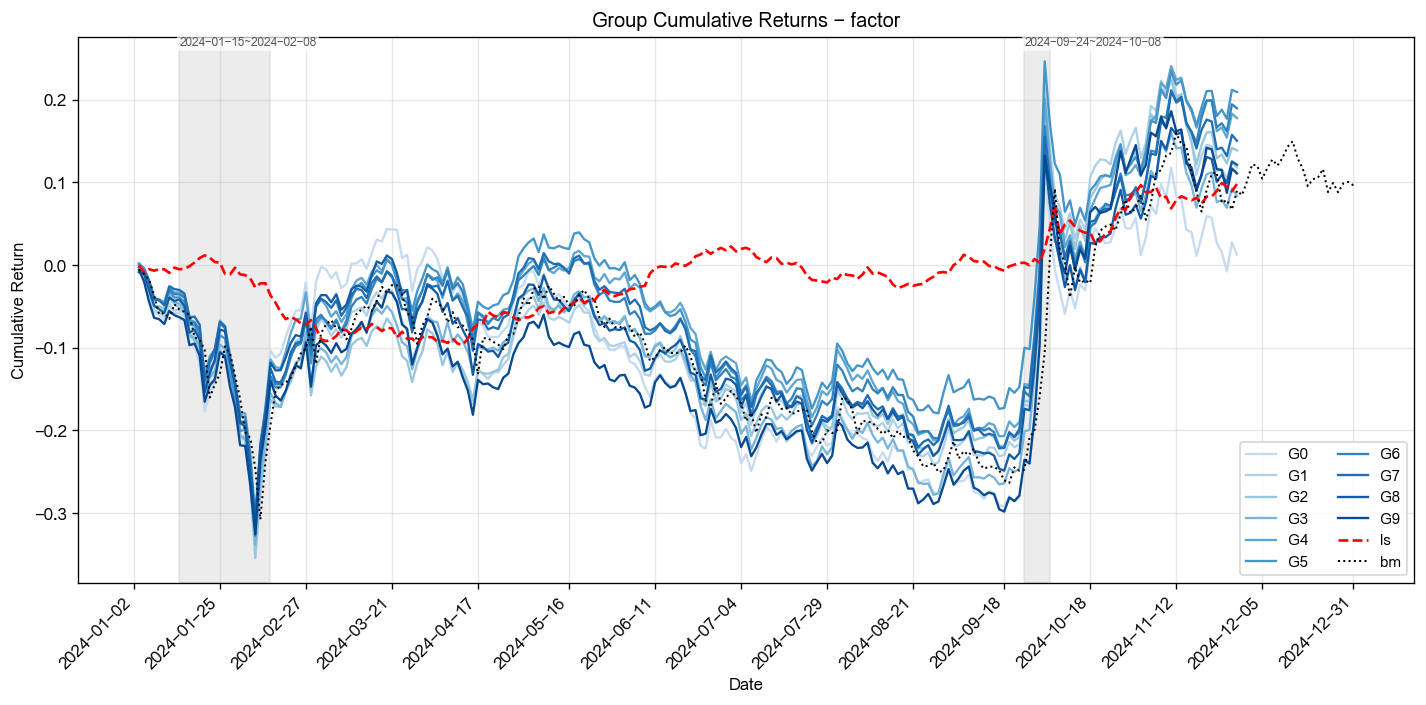
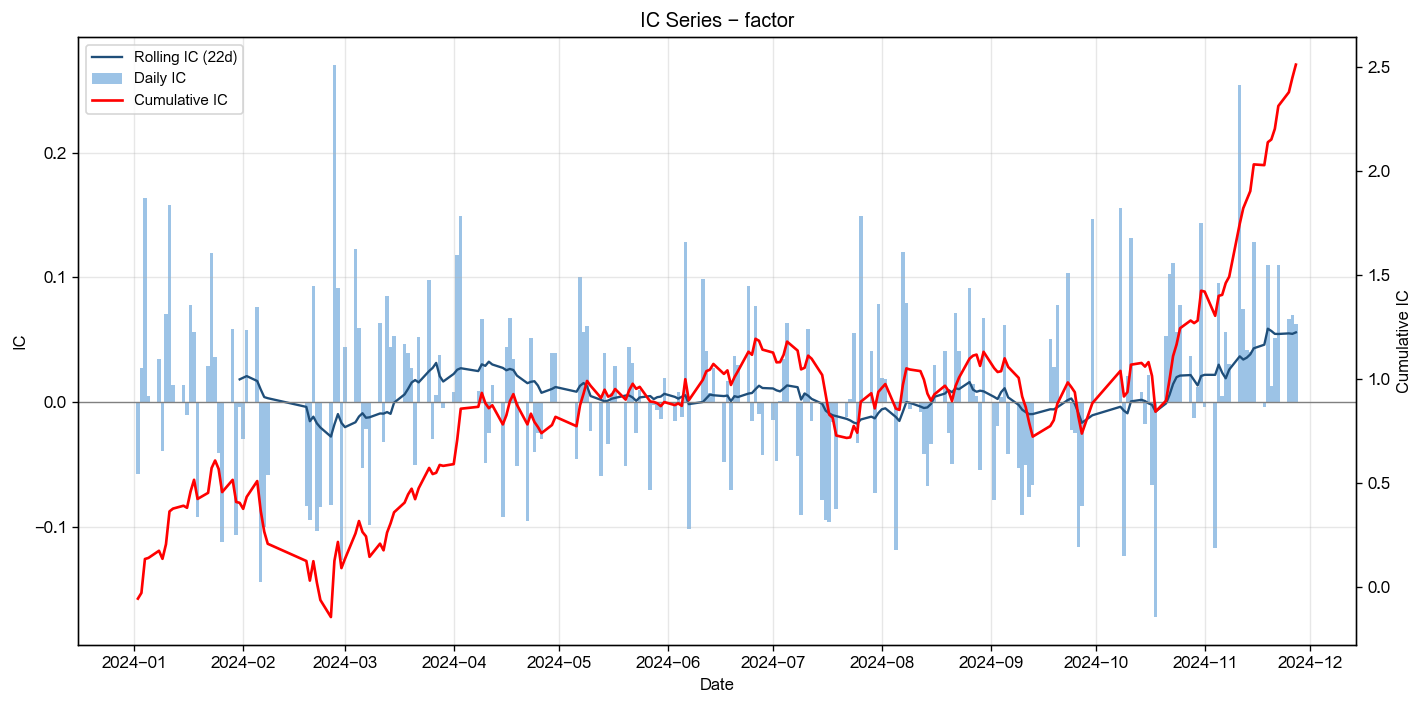
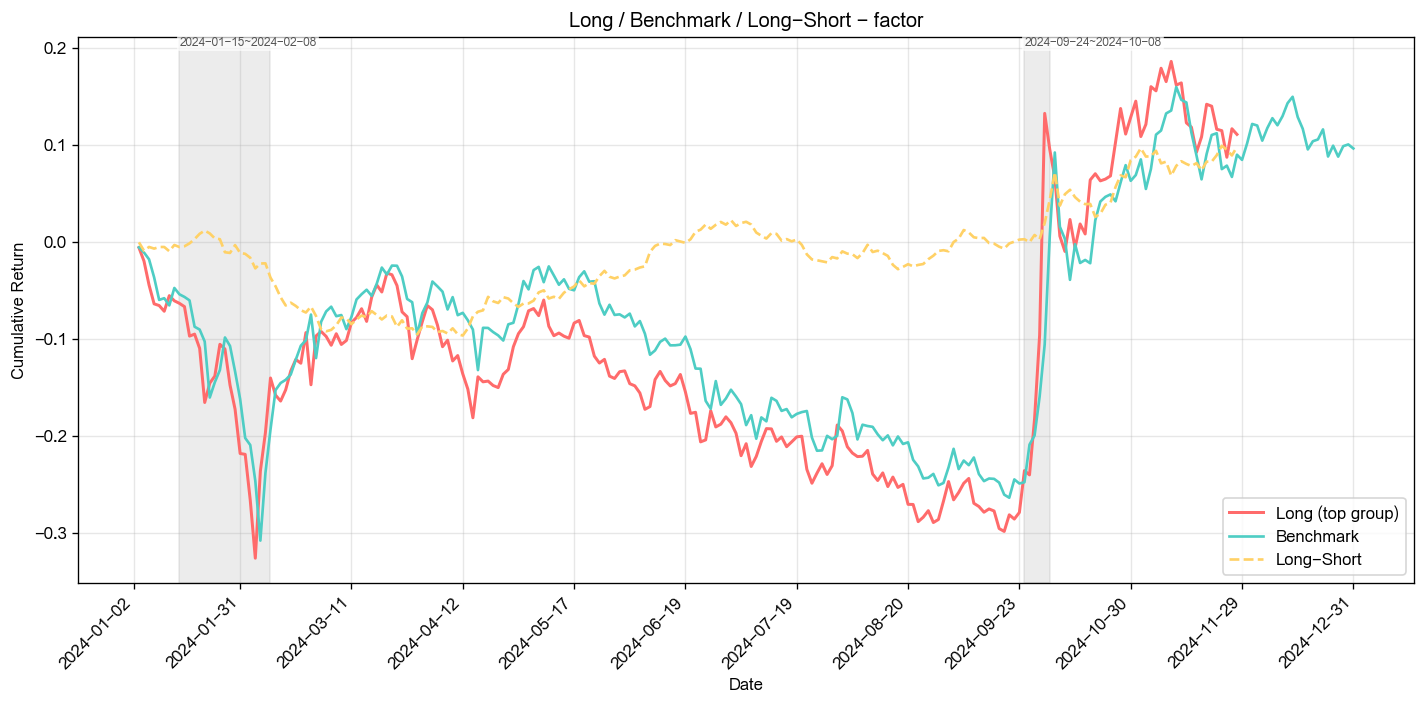
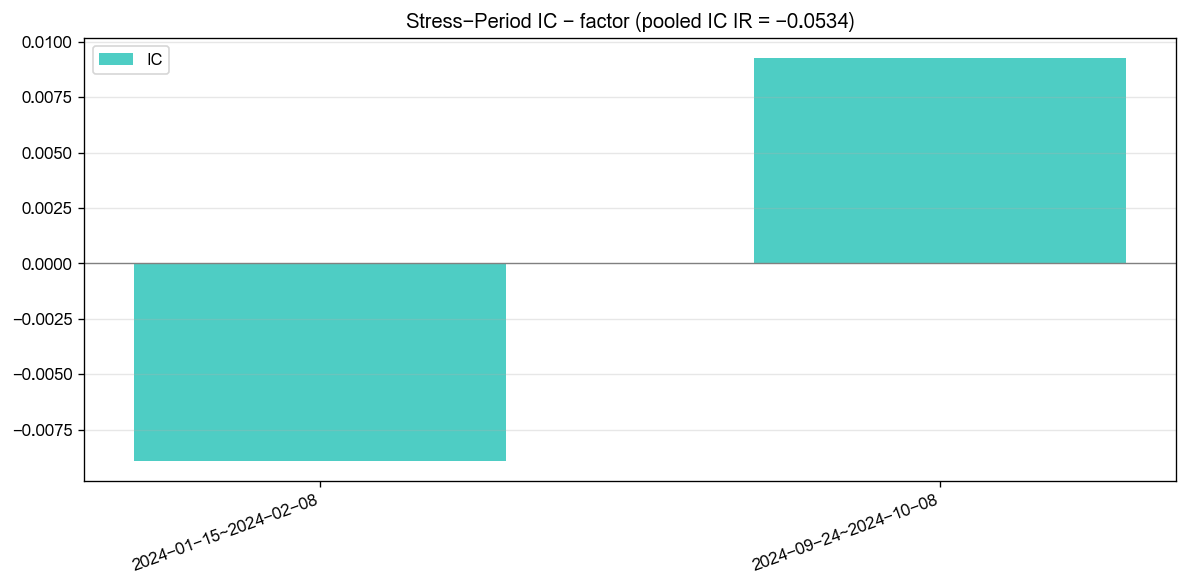
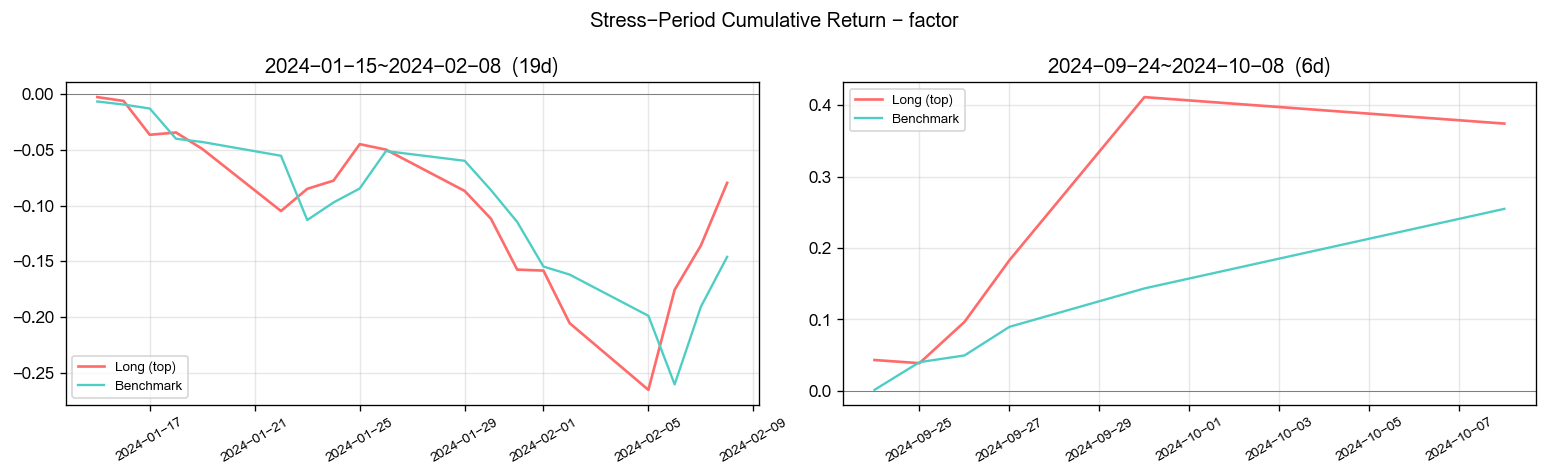

[2026-07-19 21:56:38] [info     ] ========== 因子池回归 ==========
[2026-07-19 21:56:39] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-19 21:56:39] [info     ] 获取收益率数据, 耗时: 1.474 秒
[2026-07-19 21:56:42] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.6262 秒
[2026-07-19 21:56:42] [info     ] 统计 回归结果, 耗时: 0.0996 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9722,0.0449,0.0228,1.0000
2,amount,1.6998,0.0186,0.0110,1.0000
3,netflow_amount_main,1.5446,0.0256,0.0166,1.0000
4,gross_profit_rate_ttm,1.5078,0.0069,0.0046,1.0000
5,cci_14,1.4843,0.0346,0.0233,1.0000
6,net_profit_rate_ttm,1.4574,0.0040,0.0027,0.8000
7,bias_20,1.4124,0.0290,0.0206,0.9000
8,pb,1.4077,0.0096,0.0069,1.0000
9,netflow_amount_rate_main,1.3959,0.0096,0.0069,1.0000
10,pe_ttm,1.3065,0.0029,0.0022,0.9000

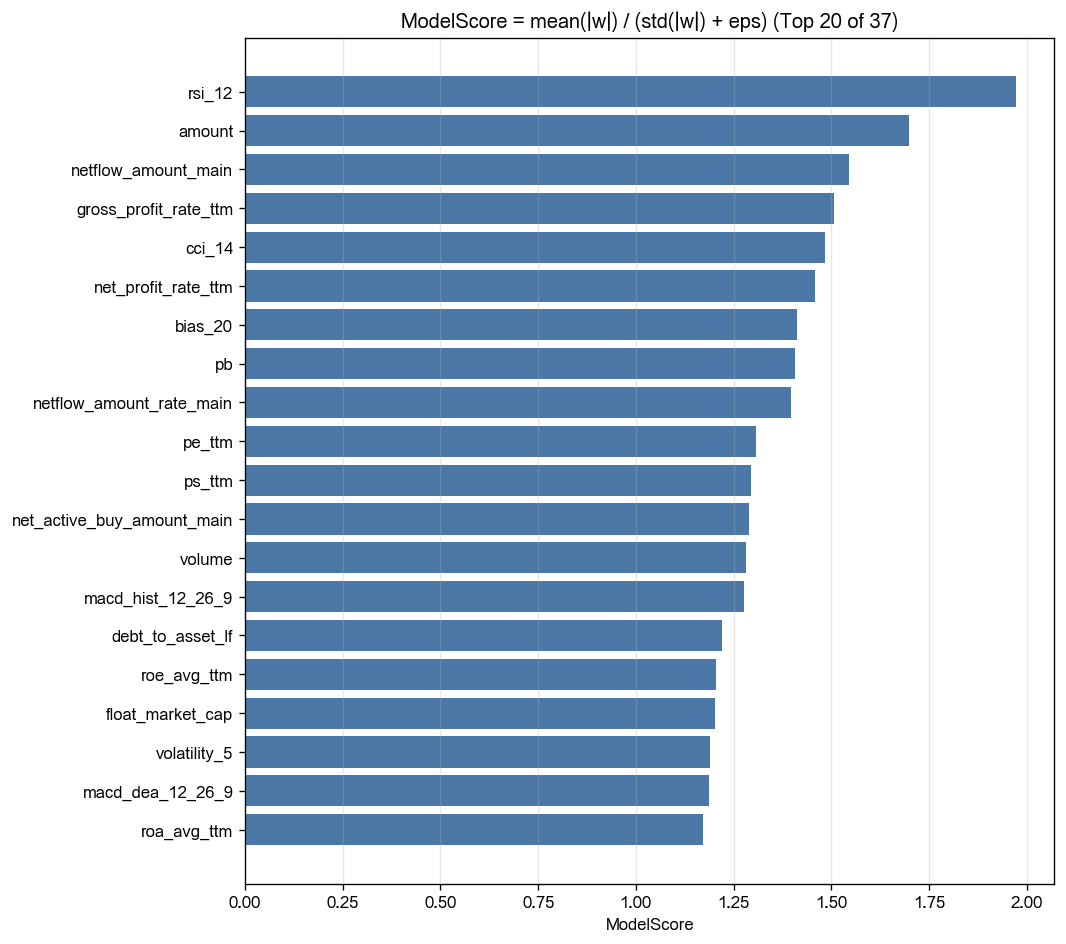
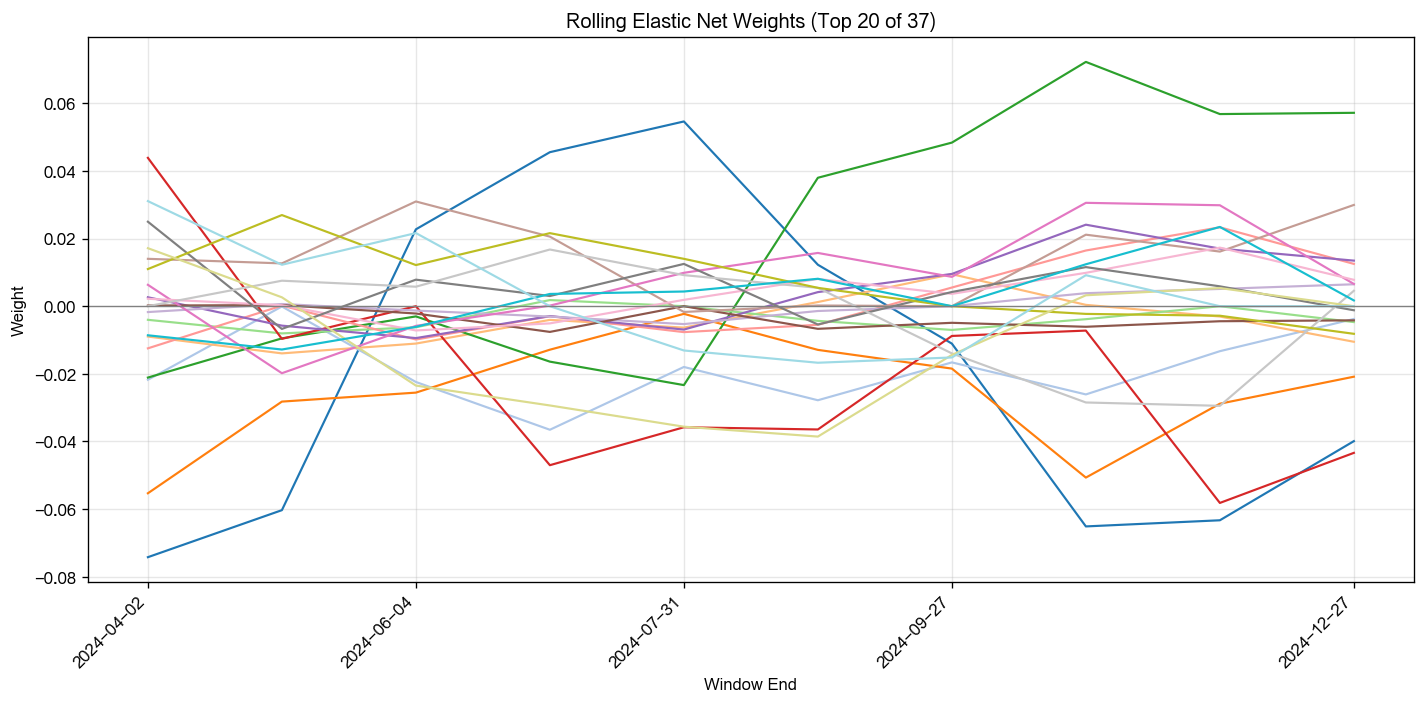
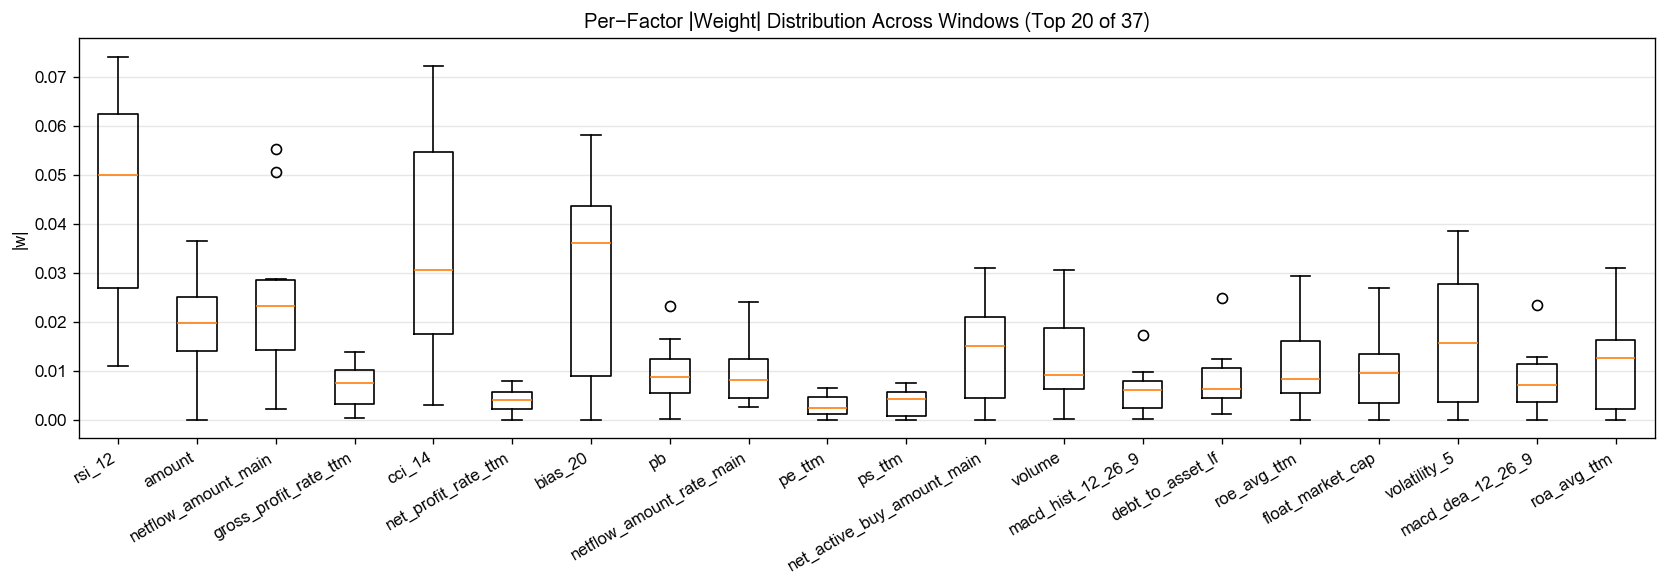
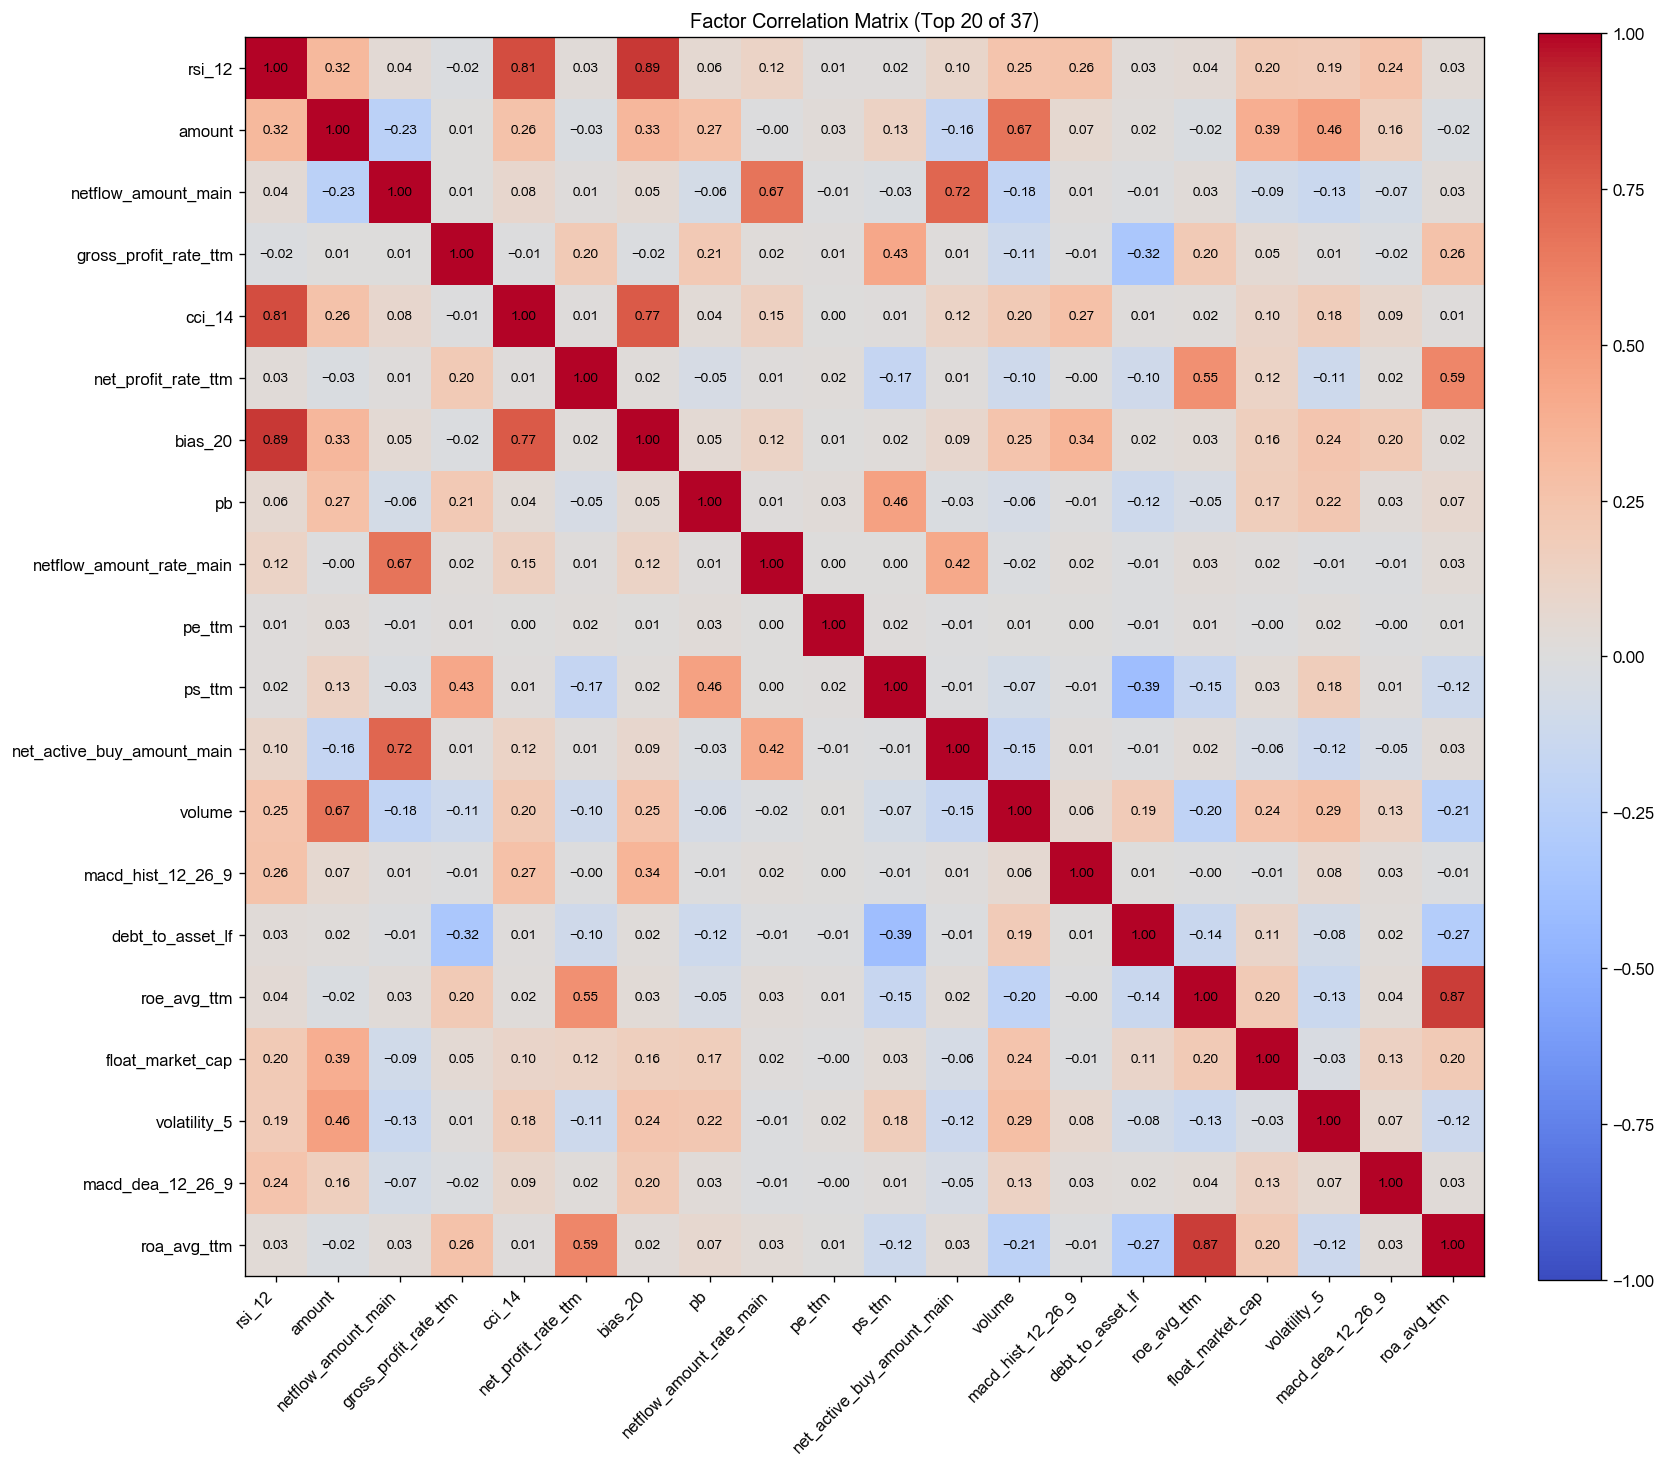

[2026-07-19 21:56:46] [warning  ] 返回的Outputs实例(size=35234180) 大于 64K, 将不会被缓存
[2026-07-19 21:56:46] [info     ] bigalpha_eval.v4 运行完成 [305.429s].


In [2]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数（XGBoost 机器学习因子示例）

    ⚠️ 赛制约定（重要）:
        评测时平台只会替换 datasources / start_date / end_date 三个入参,且 start_date~end_date
        指向的是【测试集区间】。因此训练区间必须在代码里写死（见下方 TRAIN_START/TRAIN_END）,
        本函数只用写死的训练区间拟合模型,再用平台传入的测试区间做【样本外预测】。
        切勿用传入的 start_date/end_date 训练模型——那等于在测试集上训练,既是数据泄漏, 也无法体现因子真实的样本外能力。
        后期会审查这类问题

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}，平台会在公榜/私榜自动切换。
                            可用逻辑名: "bar1m" -> 分钟 K 线表, "financial" -> 财务数据表
        start_date (str): 测试集开始时间（平台注入）
        end_date (str):   测试集结束时间（平台注入）

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 训练区间：写死，不随平台入参变化
    # ============================================================
    TRAIN_START = '2023-01-01 00:00:00'
    TRAIN_END = '2023-12-31 23:59:59'

    # ============================================================
    # 特征定义
    # ============================================================

    # financial 表查询使用的原始字段
    raw_fin_cols = [
        'operating_revenue',
        'net_profit_to_parent_shareholders',
        'total_assets',
        'total_equity_to_parent_shareholders',
    ]
    # 量价特征：
    # ret_*：不同周期收益率，捕捉短期反转和中期动量；
    # gap：隔夜跳空；
    # intraday_ret：日内收益；
    # range_pct：相对振幅；
    # close_location：收盘价在日内高低点中的位置；
    # smooth_mom：平滑趋势动量；
    # volatility_20：20日波动率；
    # volume_rel_20 / amount_rel_20：相对成交量和相对成交额。
    price_cols = [
        'ret_1d',
        'ret_5d',
        'ret_20d',
        'ret_60d',
        'gap',
        'intraday_ret',
        'range_pct',
        'close_location',
        'avg_close_rel',
        'smooth_mom',
        'volatility_20',
        'volume_rel_20',
        'amount_rel_20',
    ]

    # 财务质量特征：
    # net_margin：净利率；
    # roa_proxy：资产收益能力；
    # roe_proxy：净资产收益能力；
    # equity_ratio：权益结构。
    fin_cols = [
        'net_margin',
        'roa_proxy',
        'roe_proxy',
        'equity_ratio',
    ]

    feature_cols = price_cols + fin_cols

    # ============================================================
    # 特征工程：给定任意区间，取原始字段作为特征 + 标签（训练/预测共用同一套逻辑）
    # ============================================================
    def build_features(financial_table, bar1m_table, sd, ed):
        t0 = time.time()
        logger.info("build_features 开始", start=str(sd), end=str(ed))

        # ----- 财务原始字段（公告日 PIT，向前多取 1 年保证起点有值可填充）-----
        fin_start = pd.to_datetime(sd) - pd.Timedelta(days=365)
        fin_select = ', '.join(raw_fin_cols)
        fin_sql = f"""
        SELECT date, instrument, {fin_select}
        FROM {financial_table}
        WHERE category='lf' AND shift=0
        """
        fin = dai.query(fin_sql, filters={'date': [fin_start, ed]}).df()
        def fill_natural_dates(df: pd.DataFrame, sd: str, ed: str) -> pd.DataFrame:
            """将公告日的财务数据转换为自然日"""
            natural_dates = pd.date_range(start=sd, end=ed)
            df.set_index('date', inplace=True)
            def reindex_and_fill(group_df):
                """对每个 instrument 分组进行重新索引和条件填充的辅助函数"""
                reindexed_df = group_df.reindex(natural_dates)
                instrument_name = group_df.name
                filled_df = reindexed_df.ffill()
                filled_df['instrument'] = instrument_name
                return filled_df
            df_filled = df.groupby('instrument', group_keys=False).apply(reindex_and_fill)
            df_filled = (
                df_filled.reset_index()  # 将日期索引转为列
                .rename(columns={'index': 'date'}) # 确保日期列名为 'trade_dt'
                .dropna(subset=['instrument']) # 清理可能残留的 instrument 为 NaN 的行
            )
            return df_filled
        fin = fill_natural_dates(fin, fin_start, ed)
        fin = fin.sort_values(['instrument', 'date'])
        fin['date'] = pd.to_datetime(fin['date'])
        logger.info("财务原始字段查询完成", rows=len(fin), elapsed=round(time.time() - t0, 2))


        # ----- 量价原始字段（SQL 内日内聚合，分钟 -> 日频，取原始日线字段）-----
        t1 = time.time()
        price_start = pd.to_datetime(sd) - pd.Timedelta(days=120)
        price_sql = f"""
        SELECT
            date_trunc('day', date)::DATE           AS trading_day,
            instrument,
            ARG_MIN(open, date)                     AS open,
            MAX(high)                               AS high,
            MIN(low)                                AS low,
            ARG_MAX(close, date)                    AS close,
            SUM(volume)                             AS volume,
            SUM(amount)                             AS amount,
            AVG(close)                              AS avg_close_1d,
            MAX(close) - MIN(close)                 AS price_range
        FROM {bar1m_table}
        GROUP BY trading_day, instrument
        ORDER BY trading_day, instrument
        """
        price = dai.query(price_sql, filters={'date': [price_start, ed]}).df().rename(columns={'trading_day': 'date'})
        price['date'] = pd.to_datetime(price['date'])
        price = price.sort_values(['instrument', 'date']).reset_index(drop=True)

        raw_price_cols = [
            'open',
            'high',
            'low',
            'close',
            'volume',
            'amount',
            'avg_close_1d',
            'price_range'
        ]

        for col in raw_price_cols:
            price[col] = pd.to_numeric(
                price[col],
                errors='coerce'
            ).astype(float)

            price[col] = price[col].replace(
                [np.inf, -np.inf],
                np.nan
            )

        # ————量价特征构造————

        EPS = 1e-8

        close_group = price.groupby('instrument')['close']
        volume_group = price.groupby('instrument')['volume']
        amount_group = price.groupby('instrument')['amount']

        prev_close = close_group.shift(1)

        # 多周期收益率
        # 1日收益偏向短期反转；
        # 5日、20日、60日收益用于捕捉不同周期的动量。
        price['ret_1d'] = (
            price['close'] / (prev_close + EPS) - 1
        )

        price['ret_5d'] = close_group.pct_change(5)
        price['ret_20d'] = close_group.pct_change(20)
        price['ret_60d'] = close_group.pct_change(60)

        # 隔夜收益和日内收益
        price['gap'] = (
            price['open'] / (prev_close + EPS) - 1
        )

        price['intraday_ret'] = (
            price['close'] / (price['open'] + EPS) - 1
        )

        # 使用相对振幅，避免 price_range 受到股票绝对价格影响
        price['range_pct'] = (
            price['price_range'] / (price['close'] + EPS)
        )

        # 收盘价在当日高低区间中的位置
        # 越接近 1，说明收盘越靠近日内高点；
        # 越接近 0，说明收盘越靠近日内低点。
        high_low = price['high'] - price['low']

        price['close_location'] = (
            (price['close'] - price['low'])
            / (high_low + EPS)
        ).clip(0, 1)

        # 日内平均收盘价相对最终收盘价的偏离
        price['avg_close_rel'] = (
            price['avg_close_1d']
            / (price['close'] + EPS)
            - 1
        )

        # 20日平滑动量
        def smooth_momentum(series, window=20):
            def calc(s):
                if s.isna().any() or len(s) < window:
                    return np.nan

                y = np.log(np.maximum(s.values, EPS))
                x = np.arange(len(y))

                slope, intercept = np.polyfit(x, y, 1)
                y_pred = slope * x + intercept

                ss_res = np.sum((y - y_pred) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)

                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

                return slope * max(r2, 0)

            return series.rolling(window).apply(calc, raw=False)

        price['smooth_mom'] = (
            price.groupby('instrument')['close']
                .transform(lambda s: smooth_momentum(s, window=20))
        )

        # 20日历史波动率
        price['volatility_20'] = (
            price.groupby('instrument')['ret_1d']
                .transform(lambda s: s.rolling(20,min_periods=10).std())
        )

        # 相对成交量和相对成交额
        volume_median_20 = (
            volume_group.transform(lambda s: s.rolling(20,min_periods=10).median())
        )

        amount_median_20 = (
            amount_group.transform(lambda s: s.rolling(20,min_periods=10).median())
        )

        price['volume_rel_20'] = (
            price['volume']
            / (volume_median_20 + EPS)
        )

        price['amount_rel_20'] = (
            price['amount']
            / (amount_median_20 + EPS)
        )
        logger.info("量价原始字段查询完成", rows=len(price), elapsed=round(time.time() - t1, 2))

        # 基于日频收盘价构造标签（按标的分组后用向量化算子，避免 apply/lambda 的逐组开销）
        t2 = time.time()
        # 标签：未来 1 日收益（shift(-1) 向量化，无需 lambda）
        g = price.groupby('instrument',group_keys=False)['close']
        price['label'] = (g.shift(-1)/ price['close'].replace(0, np.nan) - 1)
        logger.info("标签计算完成", elapsed=round(time.time() - t2, 2))

        # ----- 合并财务（按公告日前向填充到日频）-----
        df = pd.merge(price, fin, how='inner', on=['date', 'instrument'])

        # ————财务质量特征————
        # 先将原始财务字段转换为数值类型，
        # 避免 Decimal/object 类型影响比率计算。
        for col in raw_fin_cols:
            df[col] = pd.to_numeric(
                df[col],
                errors='coerce'
            ).astype(float)

            df[col] = df[col].replace(
                [np.inf, -np.inf],
                np.nan
            )

        # 净利率：盈利质量
        df['net_margin'] = (
            df['net_profit_to_parent_shareholders']
            / df['operating_revenue'].replace(0, np.nan)
        )

        # 资产收益能力
        df['roa_proxy'] = (
            df['net_profit_to_parent_shareholders']
            / df['total_assets'].replace(0, np.nan)
        )

        # 净资产收益能力
        df['roe_proxy'] = (
            df['net_profit_to_parent_shareholders']
            / df[
                'total_equity_to_parent_shareholders'
            ].replace(0, np.nan)
        )

        # 权益占资产比例
        df['equity_ratio'] = (
            df['total_equity_to_parent_shareholders'] / df['total_assets'].replace(0, np.nan)
        )

        # ----- 缺失值处理：原始字段保留量纲，仅做缺失填充（不做去极值/标准化）-----
        # 注意：DuckDB 的 SUM(volume)/SUM(amount) 会返回 HUGEINT/DECIMAL，.df() 后变成 object 列
        # （存的是 Python Decimal/int 对象），XGBoost 不接受 object 列，需先强制转成数值类型。
        t3 = time.time()
        for col in feature_cols:
            df[col] = pd.to_numeric(df[col],errors='coerce')
            df[col] = df[col].replace([np.inf, -np.inf],np.nan)
        logger.info("缺失值处理完成", elapsed=round(time.time() - t3, 2))

        # 只返回落在目标区间 [sd, ed] 内的行（前面多取的缓冲期只用于算特征，不输出）
        df = df[(df['date'] >= pd.to_datetime(sd)) & (df['date'] <= pd.to_datetime(ed))]
        logger.info("build_features 结束", rows=len(df), total_elapsed=round(time.time() - t0, 2))
        return df.reset_index(drop=True)

    # ============================================================
    # 第 1 步：用【写死的训练区间】拟合模型
    # ============================================================
    logger.info("开始构建训练集", train_start=TRAIN_START, train_end=TRAIN_END)
    train_df = build_features('bigalpha_2026_financial', 'bigalpha_2026_stock_bar1m', TRAIN_START, TRAIN_END)
    train_df['label'] = train_df['label'].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=['label'])  # 末尾无未来收益的行不参与训练

    # 模型参数偏小、偏快：树更少更浅 + hist 直方图算法，牺牲少量精度换明显更快的训练速度。
    # 想追求效果可自行调大 n_estimators / max_depth。
    t_fit = time.time()
    logger.info("开始训练模型", samples=len(train_df))
    model = xgb.XGBRegressor(
        n_estimators=10, max_depth=3, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        reg_lambda=1.0, tree_method='hist', n_jobs=-1, random_state=42,
    )
    model.fit(train_df[feature_cols], train_df['label'])
    logger.info("模型训练完成", elapsed=round(time.time() - t_fit, 2))

    # ============================================================
    # 第 2 步：用【平台传入的测试区间】做样本外预测，预测值即为因子
    # ============================================================
    logger.info("开始构建测试集并预测")
    bar1m_table = datasources['bar1m']
    financial_table = datasources['financial']
    test_df = build_features(financial_table, bar1m_table, start_date, end_date)
    test_df['factor'] = model.predict(test_df[feature_cols])

    # ============================================================
    # 第 3 步：对齐中证 1000 成分股并输出
    # ============================================================
    # 只保留当日属于成分股的标的。bigalpha_2026_instruments 无需替换。
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    result = pd.merge(test_df[['date', 'instrument', 'factor']], stk_pool,
                    how='inner', on=['date', 'instrument'])
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = result.dropna(subset=['factor']).reset_index(drop=True)[['date', 'instrument', 'factor']]
    logger.info("因子构建完成", rows=len(result))
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }
    # 本地用这段区间模拟「平台注入的测试集区间」（训练区间已在 main 内写死）
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
